In [ ]:

import pandas as pd
import numpy as np
import nflreadpy as nfl
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import poisson
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import TimeSeriesSplit
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import KFold
from scipy.stats import poisson
# I like to have the okabe ito colors

OkabeItoColors = dict(orange="#E69F00", sky="#56B4E9", green="#009E73",
          pink="#CC79A7", blue="#0072B2", vermillion="#D55E00")

In [149]:
# This pulls data from the nfl read_py library
# We get data on every single play in games from 2016 to 2024


pbp = nfl.load_pbp(list(range(2006, 2024))).to_pandas()


In [150]:
# So frist we are going to make sure we know the id of the quarterback

pbp_pass = pbp.query("passer_id.notnull()").reset_index(drop=True)


# This code will help us calculate game level outcomes

pbp_pass.loc[pbp_pass.pass_touchdown.isnull(), "pass_touchdown"] = 0
pbp_pass.loc[pbp_pass.passer.isnull(),    "passer"]    = "none"
pbp_pass.loc[pbp_pass.passer_id.isnull(), "passer_id"] = "none"

qb_game = (
    pbp_pass
    .groupby(["season","week","passer_id","passer"])
    .agg(pass_td=("pass_touchdown", "sum"),
         n_passes=("pass_touchdown", "count"),
         total_line=("total_line", "mean"),
         spread_line=("spread_line","mean"),
         air_yards=("air_yards","sum"),
         interceptions=("interception","sum"),
         completions=("complete_pass","sum"),
         passing_yards=("passing_yards","sum"),
         posteam_type=("posteam_type", "first"),
        season_type=("season_type", "first"))
    .reset_index()
    .query("n_passes >= 10")
)



In [151]:
print(qb_game.groupby("pass_td").size().to_string())

pass_td
0.0    2410
1.0    3492
2.0    2571
3.0    1188
4.0     399
5.0      75
6.0      17
7.0       3


In [152]:
# Now we are going to create our feature matrix. The basic idea is for each passer and each game they appear in, we are going to compute
# their statistics on the games that occurred in that season before the game in the dataset. These will be the qb skill features used to
# estimate the passing TDs


rows = []
for season_idx in range(2006, 2024):
    for week_idx in range(1, 23):

        # NFL Games are played once a week, so we filter down the dataframe to contain games from the previous season
        # and games from the earlier weeks. We will aggregate on those data for the feature matrix

        mask = (
            (qb_game["season"] == season_idx - 1) |
            ((qb_game["season"] == season_idx) &
            (qb_game["week"] < week_idx))
        )

        # Now we compute the averages

        filtered_qb_game = (
            qb_game.loc[mask]
            .groupby(["passer_id", "passer"])
            .agg(n_games=("pass_td", "count"),
                 pass_td_rate=("pass_td", "mean"),
                 air_yards_pg=("air_yards", "mean"),
                 interceptions_pg=("interceptions", "mean"),
                 completions_pg=("completions", "mean"),
                 passing_yards_pg=("passing_yards", "mean"))
            .reset_index()
            .assign(season=season_idx, week=week_idx))
        rows.append(filtered_qb_game)

# We put all these rows together

x_feat = pd.concat(rows, ignore_index=True)


# We merge with the overall original data frame to pull in some extra context. We also throw away older info

rolling_features_df = (
    qb_game.query("season >= 2007")
    .merge(x_feat, on=["season", "week", "passer_id", "passer"], how="inner")
    .sort_values(["season", "week", "passer_id"])
    .reset_index(drop=True)
)


# These are binary variables so just recoding them as numbers

rolling_features_df["is_home"] = (rolling_features_df["posteam_type"] == "home").astype(int)
rolling_features_df["is_playoff"] = (rolling_features_df["season_type"] == "POST").astype(int)


# Take a look at the data


rolling_features_df[["season","week","passer","pass_td","pass_td_rate","total_line","air_yards_pg","interceptions_pg",
    "completions_pg","passing_yards_pg","n_games"]].head(10)

,season,week,passer,pass_td,pass_td_rate,total_line,air_yards_pg,interceptions_pg,completions_pg,passing_yards_pg,n_games
0,2007,1,J.Delhomme,3.0,1.307692,43.0,263.384615,0.846154,20.230769,215.769231,13
1,2007,1,B.Favre,0.0,1.125000,41.5,331.562500,1.125000,21.437500,242.812500,16
2,2007,1,J.Garcia,0.0,1.500000,40.5,274.125000,0.250000,18.375000,209.125000,8
3,2007,1,T.Green,1.0,0.888889,34.0,199.555556,1.222222,15.000000,161.000000,9
4,2007,1,M.Hasselbeck,1.0,1.500000,40.5,320.357143,1.285714,17.571429,205.500000,14
5,2007,1,D.Huard,0.0,1.222222,37.5,213.333333,0.111111,16.222222,202.666667,9
6,2007,1,J.Kitna,3.0,1.312500,39.5,315.000000,1.375000,23.250000,263.000000,16
7,2007,1,P.Manning,3.0,1.700000,52.5,343.100000,0.800000,22.950000,271.550000,20
8,2007,1,D.McNabb,1.0,1.700000,41.5,279.200000,0.600000,18.000000,261.200000,10
9,2007,1,S.McNair,0.0,1.066667,39.5,240.800000,0.866667,20.733333,214.600000,15


In [153]:
# Get the target variable and extract the features we want to use
# We could in theory use pipelines but the data is clean and Poisson regression
# doesn't require preprocessing, and we don't have complex categorical features

# This is the very basic model from the Eager book

X_base = rolling_features_df[["pass_td_rate", "total_line"]].values
y = rolling_features_df["pass_td"].values



model_simple_full = PoissonRegressor(alpha=0, max_iter=1000)
model_simple_full.fit(X_base, y)

print(model_simple_full.coef_)

[0.30939192 0.02309926]


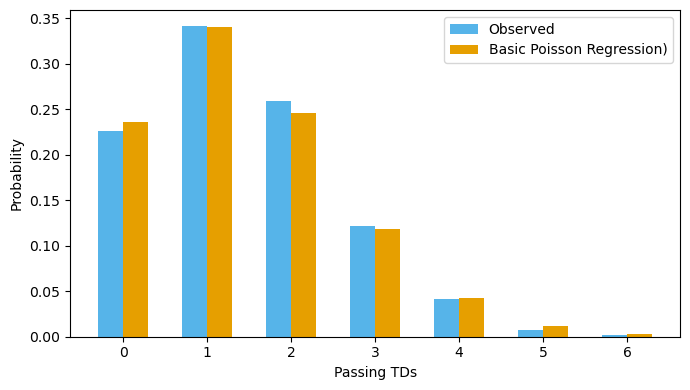

In [154]:
td_mean = y.mean()
td_var  = y.var()



fig, ax = plt.subplots(figsize=(7, 4))
obs = pd.Series(y).value_counts().sort_index()
obs_p = obs / obs.sum()
ks = np.arange(0, 7)
ax.bar(ks - 0.15, [obs_p.get(k, 0) for k in ks], 0.3,
       label="Observed", color=OkabeItoColors["sky"])
ax.bar(ks + 0.15, poisson.pmf(ks, td_mean), 0.3,
       label=f"Basic Poisson Regression)", color=OkabeItoColors["orange"])
ax.set_xlabel("Passing TDs"); ax.set_ylabel("Probability")
ax.set_xticks(ks); ax.legend(); plt.tight_layout(); plt.show()

                    GeneralizedPoisson Regression Results                     
Dep. Variable:                      y   No. Observations:                 9281
Model:             GeneralizedPoisson   Df Residuals:                     9278
Method:                           MLE   Df Model:                            2
Date:                Tue, 03 Mar 2026   Pseudo R-squ.:                 0.02998
Time:                        22:27:30   Log-Likelihood:                -13441.
converged:                       True   LL-Null:                       -13857.
Covariance Type:            nonrobust   LLR p-value:                4.015e-181
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1147      0.080    -13.939      0.000      -1.271      -0.958
x1             0.3060      0.016     18.659      0.000       0.274       0.338
x2             0.0227      0.002     11.743      0.0

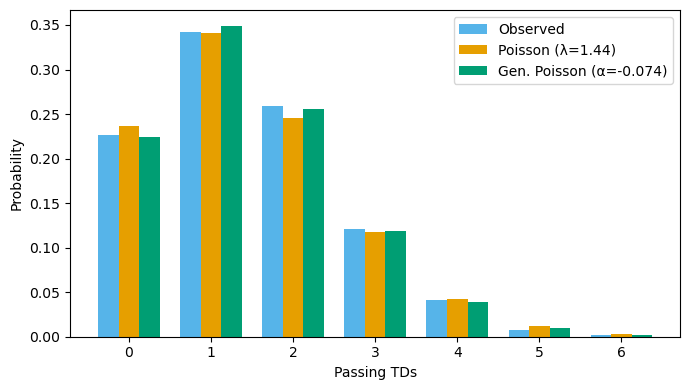

In [158]:
# Here is very basic cross validation for this model

kf_random = KFold(n_splits=5, shuffle=True, random_state=65)


pw_all = []

for tr, te in kf_random.split(X_base):

    model_basic = PoissonRegressor(alpha=0, max_iter=1000)
    model_basic.fit(X_base[tr], y[tr])
    mu_hat = model_basic.predict(X_base[te])
    score = poisson.logpmf(y[te], mu_hat)
    pw_all.append(score)

 
pw_all = np.concatenate(pw_all)

pw_all.mean()

np.float64(-1.4544564601835692)

In [96]:
rolling_features_df

,season,week,passer_id,passer,pass_td,n_passes,total_line,spread_line,air_yards,interceptions,...,season_type,defteam,n_games,pass_td_rate,air_yards_pg,interceptions_pg,completions_pg,passing_yards_pg,is_home,is_playoff
0,2000,1,00-0000722,T.Banks,1.0,33,37.0,-2.5,0.0,0.0,...,REG,PIT,11,1.545455,0.000000,0.727273,15.363636,194.181818,0,0
1,2000,1,00-0001218,S.Beuerlein,1.0,36,47.5,10.5,0.0,0.0,...,REG,WAS,16,2.250000,0.000000,0.937500,21.437500,277.250000,0,0
2,2000,1,00-0001335,J.Blake,0.0,45,40.5,0.0,0.0,1.0,...,REG,DET,13,1.153846,0.000000,0.923077,16.153846,201.384615,1,0
3,2000,1,00-0001361,D.Bledsoe,1.0,50,36.0,-3.0,0.0,0.0,...,REG,TB,16,1.187500,0.000000,1.312500,19.062500,249.062500,1,0
4,2000,1,00-0002110,M.Brunell,1.0,38,38.5,-10.5,0.0,0.0,...,REG,CLE,17,1.000000,0.000000,0.647059,16.647059,199.470588,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13065,2023,21,00-0033873,P.Mahomes,1.0,50,44.0,4.5,233.0,0.0,...,POST,BAL,38,2.052632,254.368421,0.684211,24.947368,279.289474,0,1
13066,2023,21,00-0034796,L.Jackson,1.0,47,44.0,4.5,344.0,1.0,...,POST,KC,28,1.535714,240.857143,0.500000,18.678571,216.464286,1,1
13067,2023,21,00-0037834,B.Purdy,1.0,36,52.5,7.5,283.0,1.0,...,POST,DET,26,1.846154,218.884615,0.576923,18.538462,248.153846,1,1
13068,2023,22,00-0033873,P.Mahomes,2.0,55,47.0,-1.5,280.0,1.0,...,POST,SF,39,2.025641,253.820513,0.666667,25.076923,278.307692,1,1


In [163]:
feature_sets = {
    "Basic":  ["pass_td_rate","total_line"],
    "Betting Only": ["total_line","spread_line"],
    "Throwing Focus":  ["pass_td_rate", "completions_pg","air_yards_pg","passing_yards_pg","interceptions_pg"],
    "Situation Focused":  ["total_line", "spread_line", "is_home","is_playoff","n_games","week"],
    "Everything": ["pass_td_rate", "total_line", "completions_pg","air_yards_pg","passing_yards_pg","interceptions_pg","spread_line", "is_home","is_playoff","n_games","week"],
    "My Best Idea": ["pass_td_rate","total_line","spread_line","is_home","air_yards_pg","completions_pg","passing_yards_pg"]
}

# Empty dict to store the results
cv_results = {}

kf_random = KFold(n_splits=10, shuffle=True, random_state=65)


for name, cols in feature_sets.items():
    Xm = rolling_features_df[cols].values # So we pull out the features of the matrix we want
    pw_all = [] # Reset out pointwise score
    for tr, te in kf_random.split(Xm):
        model = PoissonRegressor(alpha=0, max_iter=10000)
        model.fit(Xm[tr], y[tr]) # Fit on the training fold
        yhat = model.predict(Xm[te]) # Get test set predictions
        ll = poisson.logpmf(y[te], yhat) 
        pw_all.append(ll) # Add our pointwise score

    pw_all = np.concatenate(pw_all) # Turn the list into an array
    cv_results[name] = dict(
        mean_ll=pw_all.mean(), # Mean Score
        se_ll=np.std(pw_all, ddof=1) / np.sqrt(len(pw_all)), # Standard error
    )


In [164]:
cv_results

{'Basic': {'mean_ll': np.float64(-1.454444634787114),
  'se_ll': np.float64(0.005925219868525511)},
 'Betting Only': {'mean_ll': np.float64(-1.4707021520454624),
  'se_ll': np.float64(0.005972064351017418)},
 'Throwing Focus': {'mean_ll': np.float64(-1.4557957310955283),
  'se_ll': np.float64(0.005962218583291069)},
 'Situation Focused': {'mean_ll': np.float64(-1.4571133098563458),
  'se_ll': np.float64(0.005981578407885951)},
 'Everything': {'mean_ll': np.float64(-1.4480217995933713),
  'se_ll': np.float64(0.005939697494662817)},
 'My Best Idea': {'mean_ll': np.float64(-1.4511486330351246),
  'se_ll': np.float64(0.005923626339556512)}}

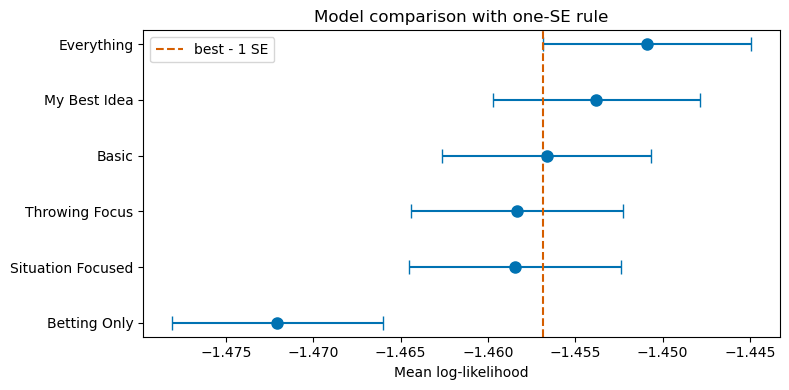

In [171]:
sorted_models = sorted(cv_results.items(), key=lambda x: x[1]["mean_ll"], reverse=True)
names = [nm for nm, _ in sorted_models]
means = [r["mean_ll"] for _, r in sorted_models]
ses = [r["se_ll"] for _, r in sorted_models]

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = list(range(len(names)))

ax.errorbar(means, y_pos, xerr=ses, fmt="o", color=OkabeItoColors["blue"],
            capsize=5, markersize=8, linewidth=1.5)

threshold = means[0] - ses[0]
ax.axvline(threshold, color=OkabeItoColors["vermillion"], ls="--", lw=1.5,
           label=f"best - 1 SE")

ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.set_xlabel("Mean log-likelihood")
ax.set_title("Model comparison with one-SE rule")
ax.legend()
plt.tight_layout()
ax.invert_yaxis()
plt.show()

In [172]:
def plot_cv_comparison(cv_results):
    sorted_models = sorted(cv_results.items(), key=lambda x: x[1]["mean_ll"], reverse=True)
    names = [nm for nm, _ in sorted_models]
    means = [r["mean_ll"] for _, r in sorted_models]
    ses = [r["se_ll"] for _, r in sorted_models]

    fig, ax = plt.subplots(figsize=(8, 4))
    y_pos = list(range(len(names)))

    ax.errorbar(means, y_pos, xerr=ses, fmt="o", color=OkabeItoColors["blue"],
                capsize=5, markersize=8, linewidth=1.5)

    threshold = means[0] - ses[0]
    ax.axvline(threshold, color=OkabeItoColors["vermillion"], ls="--", lw=1.5,
               label="best - 1 SE")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(names)
    ax.set_xlabel("Mean log-likelihood (higher is better)")
    ax.set_title("Model comparison with one-SE rule")
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

In [170]:
# Can do time series cross validation


tscv = TimeSeriesSplit(n_splits=17)



# Empty dict to store the results
cv_results = {}



for name, cols in feature_sets.items():
    Xm = rolling_features_df[cols].values # So we pull out the features of the matrix we want
    pw_all = [] # Reset out pointwise score
    for tr, te in tscv.split(Xm):
        model = PoissonRegressor(alpha=0, max_iter=10000)
        model.fit(Xm[tr], y[tr]) # Fit on the training fold
        yhat = model.predict(Xm[te]) # Get test set predictions
        ll = poisson.logpmf(y[te], yhat) 
        pw_all.append(ll) # Add our pointwise score

    pw_all = np.concatenate(pw_all) # Turn the list into an array
    cv_results[name] = dict(
        mean_ll=pw_all.mean(), # Mean Score
        se_ll=np.std(pw_all, ddof=1) / np.sqrt(len(pw_all)), # Standard error
    )

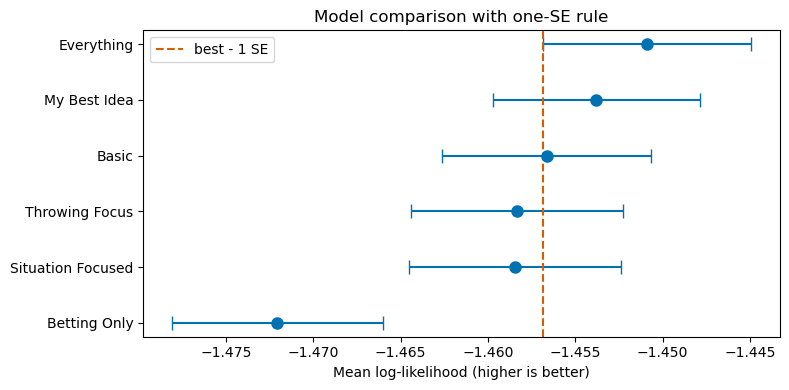

In [173]:
plot_cv_comparison(cv_results)


In [174]:
tscv = TimeSeriesSplit(n_splits=5)
K = 5
cv_results = {}

y = team_data_df["pass_td"].values

for name, cols in feature_sets.items():
    Xm = team_data_df[cols].values
    
    # full-data fit for bias correction
    full_mod = PoissonRegressor(alpha=0, max_iter=10000)
    full_mod.fit(Xm, y)
    mu_full = np.clip(full_mod.predict(Xm), 1e-8, None)
    L_full = poisson.logpmf(y, mu_full)
    
    pw_all = []
    L_folds = np.zeros((len(y), K))
    
    for k, (tr, te) in enumerate(tscv.split(Xm)):
        mk = PoissonRegressor(alpha=0, max_iter=10000)
        mk.fit(Xm[tr], y[tr])
        
        # CV scoring (test fold only)
        mu_te = np.clip(mk.predict(Xm[te]), 1e-8, None)
        pw_all.append(poisson.logpmf(y[te], mu_te))
        
        # bias correction (all observations)
        mu_all = np.clip(mk.predict(Xm), 1e-8, None)
        L_folds[:, k] = poisson.logpmf(y, mu_all)
    
    pw_all = np.concatenate(pw_all)
    kappa = (L_full - L_folds.mean(axis=1)).mean()
    
    cv_results[name] = dict(
        mean_ll=pw_all.mean(),
        se_ll=np.std(pw_all, ddof=1) / np.sqrt(len(pw_all)),
        corrected_ll=pw_all.mean() + kappa,
        within_sample_ll=L_full.mean(),
    )

print(f"{'Model':<25} {'Raw LL':>10} {'Corrected':>10} {'Within':>10} {'SE':>8}")
print("-" * 66)
for nm, r in cv_results.items():
    print(f"{nm:<25} {r['mean_ll']:10.4f} {r['corrected_ll']:10.4f} "
          f"{r['within_sample_ll']:10.4f} {r['se_ll']:8.4f}")

Model                         Raw LL  Corrected     Within       SE
------------------------------------------------------------------
Basic                        -1.4516    -1.4514    -1.4422   0.0058
Betting Only                 -1.4683    -1.4676    -1.4577   0.0060
Throwing Focus               -1.4534    -1.4530    -1.4439   0.0058
Situation Focused            -1.4569    -1.4556    -1.4450   0.0061
Everything                   -1.4527    -1.4460    -1.4364   0.0055
My Best Idea                 -1.4507    -1.4490    -1.4399   0.0056


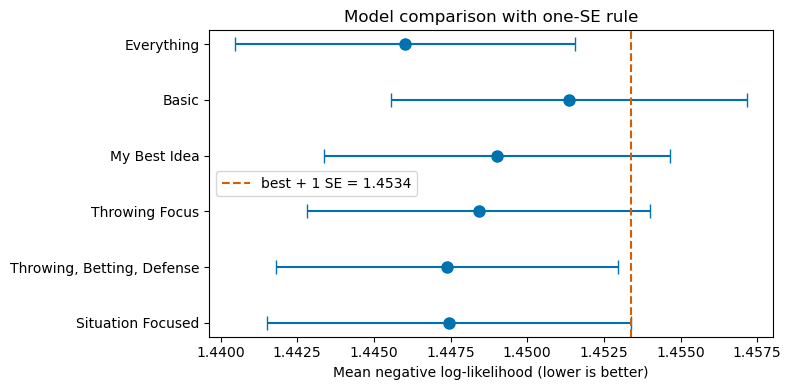

In [135]:
sorted_models = sorted(cv_results.items(), key=lambda x: x[1]["mean_nll"])
names = [nm for nm, _ in sorted_models]
means = [r["corrected_nll"] for _, r in sorted_models]
ses = [r["se_nll"] for _, r in sorted_models]

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = range(len(names))

ax.errorbar(means, y_pos, xerr=ses, fmt="o", color=OI["blue"],
            capsize=5, markersize=8, linewidth=1.5)

threshold = means[0] + ses[0]
ax.axvline(threshold, color=OI["vermillion"], ls="--", lw=1.5,
           label=f"best + 1 SE = {threshold:.4f}")

ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.set_xlabel("Mean negative log-likelihood (lower is better)")
ax.set_title("Model comparison with one-SE rule")
ax.legend()
plt.tight_layout()
plt.show()

In [147]:
B = 2000
n = len(y)
boot_lambdas = np.zeros(B)

feature_cols=feature_sets['Basic']
X_base = rolling_features_df[["pass_td_rate", "total_line","spread_line"]].values

# pick a specific QB-game to predict
X_target = team_data_df.query('passer == "P.Mahomes" & season == 2022 & week == 22')[feature_cols].values

for b in range(B):
    idx = np.random.choice(n, n, replace=True)
    m = PoissonRegressor(alpha=0, max_iter=10000)
    m.fit(X_base[idx], y[idx])
    boot_lambdas[b] = m.predict(X_target)[0]

lo, hi = np.percentile(boot_lambdas, [2.5, 97.5])

print(f"Bootstrap 95% CI for lambda: [{lo:.3f}, {hi:.3f}]")
print(f"P(over 2.5 TDs) at lo: {1 - poisson.cdf(2, lo):.3f}")
print(f"P(over 2.5 TDs) at hi: {1 - poisson.cdf(2, hi):.3f}")

Bootstrap 95% CI for lambda: [1.410, 1.508]
P(over 2.5 TDs) at lo: 0.169
P(over 2.5 TDs) at hi: 0.193


In [148]:
X_target

array([[ 2.38461538, 51.        ,  1.        ]])